# v3 — Binding Failure: Co-presence Degradation + Sub-question Decomposition

## Experiment Card

**Grounding:**  
- Koishigarina et al. (ICLR 2026): binding info exists in frozen features; cross-modal alignment fails  
- Li (Brown 2023): models answer sub-questions correctly but fail the composite question in 22.8% of cases  

### 1. Core claim being tested
A linear probe trained on single-object crops will degrade when applied to objects in two-object scenes,
and the magnitude of degradation will be larger for *different-state* (binding-ambiguous) scenes
than for *same-state* scenes. Furthermore, replicating Li (2023): the model may correctly identify
each object's state independently but fail to attribute the correct state to the correct object
in a joint prediction.

### 2. Experiments
| Cell | What | Maps to |
|---|---|---|
| `b3-copresence` | Single-object probe AP vs two-object AP (same-state vs diff-state) | B2 |
| `b3-subq` | Sub-question decomposition on compositionality scenes | A3 / Paper 3 Table A3 |
| `b3-table` | Summary table | Binding failure quantification |

### 3. Dependent variable
- AP drop: `AP(single-object) − AP(two-object bbox crop)`
- Sub-question table: P(composite correct | k sub-questions correct) for k ∈ {0, 1, 2}

### 4. Success criteria
- AP drop is larger for diff-state than same-state scenes → binding ambiguity causes the degradation
- P(composite wrong | both sub-questions correct) > 0 → 'knows the parts, fails the whole'
- Effect larger for full/empty than for easily-distinguished pairs (e.g. open/closed)

In [1]:
import pickle, random, warnings
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

import torch
import torch.nn.functional as F
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import average_precision_score
from sklearn.model_selection import train_test_split
from transformers import AutoProcessor, AutoModel

warnings.filterwarnings('ignore')
random.seed(42); np.random.seed(42)

device = ('cuda' if torch.cuda.is_available()
          else 'mps'  if torch.backends.mps.is_available() else 'cpu')
print(f'Device: {device}')

DATA = Path('../../data')

# Single-object sim crops
with open(DATA / 'sim_crops_all.pkl', 'rb') as f:
    crops = pickle.load(f)

cache       = np.load(DATA / 'embeddings_all_cache.npz')
siglip_embs = cache['embeddings']
labels_all  = np.array([c['label']     for c in crops])
pairs_all   = np.array([c['pair_name'] for c in crops])

# Compositionality scenes (bowl + cup, all 4 state combos)
with open(DATA / 'compositionality_scenes.pkl', 'rb') as f:
    comp = pickle.load(f)
print(f'Single-object crops: {len(crops)}')
print(f'Compositionality scenes: {len(comp)}')
print(f'Scene combos: {set((s["bowl_state"], s["cup_state"]) for s in comp)}')

# SigLIP 2 (used for embedding extraction and zero-shot)
SG_ID  = 'google/siglip2-so400m-patch16-384'
sg_proc  = AutoProcessor.from_pretrained(SG_ID)
sg_model = AutoModel.from_pretrained(SG_ID).to(device).eval()

def embed_images(images):
    """Extract SigLIP 2 pooler embeddings for a list of PIL images."""
    embs = []
    with torch.no_grad():
        for img in images:
            pv = sg_proc(images=[img], return_tensors='pt')['pixel_values'].to(device)
            e  = sg_model.vision_model(pixel_values=pv).pooler_output.squeeze(0)
            embs.append(e.cpu().float().numpy())
    return np.stack(embs)

# Train probe on single-object crops (full/empty pair only)
fe_mask = pairs_all == 'full_empty'
fe_embs = siglip_embs[fe_mask]
fe_lbl  = labels_all[fe_mask]
tr_idx, te_idx = train_test_split(np.arange(len(fe_lbl)), test_size=0.2,
                                   stratify=fe_lbl, random_state=42)
scaler = StandardScaler().fit(fe_embs[tr_idx])
clf    = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
clf.fit(scaler.transform(fe_embs[tr_idx]), fe_lbl[tr_idx])
baseline_ap = average_precision_score(
    fe_lbl[te_idx],
    clf.predict_proba(scaler.transform(fe_embs[te_idx]))[:, 1]
)
print(f'\nSingle-object probe AP (full/empty, test set): {baseline_ap:.3f}')

/Users/timrutjens/School/EAI/Experiments/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: mps
Single-object crops: 758
Compositionality scenes: 40
Scene combos: {('full', 'empty'), ('empty', 'full'), ('full', 'full'), ('empty', 'empty')}


Loading weights: 100%|██████████| 888/888 [00:00<00:00, 8367.41it/s]



Single-object probe AP (full/empty, test set): 0.743


Extracting bbox crop embeddings from compositionality scenes...
Saved: (80, 1152)

AP — single-object baseline:          0.743
AP — two-object same-state crops:     0.901  (Δ = +0.158)
AP — two-object diff-state crops:     0.901  (Δ = +0.158)
Same→diff binding penalty:            +0.000


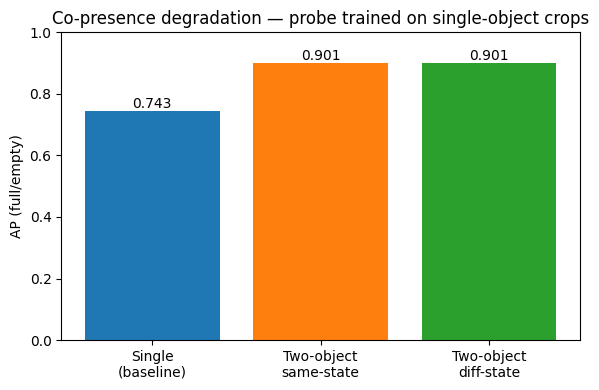

In [2]:
# Co-presence degradation — B2
# Apply the single-object probe (trained above) to bbox crops extracted from
# compositionality scenes. Three conditions:
#   1. Single-object (baseline)
#   2. Two-object same-state (bowl and cup both full, or both empty)
#   3. Two-object different-state (one full, one empty)
#
# Prediction: AP(diff-state) < AP(same-state) < AP(single)
# A large same→diff drop isolates binding ambiguity from simple distractor effects.

def crop_bbox(img, bbox):
    x1, y1, x2, y2 = [int(v) for v in bbox]
    return img.crop((x1, y1, x2, y2))

CACHE_CO = DATA / 'comp_bbox_embs.npy'
CACHE_LBL = DATA / 'comp_bbox_labels.npy'
CACHE_SAME = DATA / 'comp_bbox_same.npy'

if CACHE_CO.exists():
    co_embs  = np.load(CACHE_CO)
    co_lbls  = np.load(CACHE_LBL)
    co_same  = np.load(CACHE_SAME)
    print(f'Loaded compositionality crop embeddings: {co_embs.shape}')
else:
    print('Extracting bbox crop embeddings from compositionality scenes...')
    co_embs, co_lbls, co_same = [], [], []
    for s in comp:
        bowl_crop = crop_bbox(s['image'], s['bowl_bbox'])
        cup_crop  = crop_bbox(s['image'], s['cup_bbox'])
        bowl_lbl  = 1 if s['bowl_state'] == 'full' else 0
        cup_lbl   = 1 if s['cup_state']  == 'full' else 0
        same = s['same_state']
        for img, lbl in [(bowl_crop, bowl_lbl), (cup_crop, cup_lbl)]:
            emb = embed_images([img])[0]
            co_embs.append(emb); co_lbls.append(lbl); co_same.append(same)
    co_embs = np.stack(co_embs); co_lbls = np.array(co_lbls); co_same = np.array(co_same)
    np.save(CACHE_CO, co_embs); np.save(CACHE_LBL, co_lbls); np.save(CACHE_SAME, co_same)
    print(f'Saved: {co_embs.shape}')

# Apply probe (trained on single-object crops)
scores_co  = clf.predict_proba(scaler.transform(co_embs))[:, 1]

ap_same = average_precision_score(co_lbls[co_same],  scores_co[co_same])
ap_diff = average_precision_score(co_lbls[~co_same], scores_co[~co_same])

print(f'\nAP — single-object baseline:          {baseline_ap:.3f}')
print(f'AP — two-object same-state crops:     {ap_same:.3f}  (Δ = {ap_same - baseline_ap:+.3f})')
print(f'AP — two-object diff-state crops:     {ap_diff:.3f}  (Δ = {ap_diff - baseline_ap:+.3f})')
print(f'Same→diff binding penalty:            {ap_diff - ap_same:+.3f}')

fig, ax = plt.subplots(figsize=(6, 4))
conditions = ['Single\n(baseline)', 'Two-object\nsame-state', 'Two-object\ndiff-state']
aps = [baseline_ap, ap_same, ap_diff]
bars = ax.bar(conditions, aps, color=['C0', 'C1', 'C2'])
ax.set_ylabel('AP (full/empty)'); ax.set_ylim(0, 1)
ax.set_title('Co-presence degradation — probe trained on single-object crops')
for b, v in zip(bars, aps):
    ax.text(b.get_x() + b.get_width()/2, v + 0.01, f'{v:.3f}', ha='center', fontsize=10)
plt.tight_layout(); plt.show()

In [3]:
# Sub-question decomposition — A3 / Paper 3 Table A3 adaptation
#
# Paper 3 found: BLIP-2 answers both sub-questions correctly in ~51% of cases
# but still fails the composite answer 22.8% of those times.
#
# Here: sub-questions are answered by the single-object probe on bbox crops.
# Composite question: "which object is full?" answered by the SAME probe
# applied to each crop and comparing scores — i.e. does the probe correctly
# rank the full object above the empty object in the same scene?
#
# Build 3×2 table: composite_correct × n_subqs_correct (0, 1, 2)

# Pair up bowl and cup crops from the same scene
# comp[i] has bowl and cup — co_embs were extracted in pairs (bowl first, then cup)
n_scenes = len(comp)
bowl_embs_co = co_embs[0::2]   # [n_scenes, 1152]
cup_embs_co  = co_embs[1::2]   # [n_scenes, 1152]
bowl_lbls_co = co_lbls[0::2]   # 1 = full
cup_lbls_co  = co_lbls[1::2]

bowl_scores = clf.predict_proba(scaler.transform(bowl_embs_co))[:, 1]
cup_scores  = clf.predict_proba(scaler.transform(cup_embs_co))[:, 1]

# Sub-question correctness: did the probe correctly classify each individual crop?
bowl_subq_correct = (bowl_scores > 0.5) == bowl_lbls_co.astype(bool)
cup_subq_correct  = (cup_scores  > 0.5) == cup_lbls_co.astype(bool)
n_subqs_correct   = bowl_subq_correct.astype(int) + cup_subq_correct.astype(int)

# Composite question: which object is full?
# Correct if the probe assigns higher score to the full object.
# For same-state scenes, both objects have the same state — mark as ambiguous.
comp_same_state = np.array([s['same_state'] for s in comp])
comp_correct    = np.zeros(n_scenes, dtype=bool)
for i, s in enumerate(comp):
    if s['same_state']:  # ambiguous — skip from composite eval
        comp_correct[i] = True  # trivially correct (both are full or both empty)
    elif s['bowl_state'] == 'full':  # bowl should have higher score
        comp_correct[i] = bowl_scores[i] > cup_scores[i]
    else:  # cup should have higher score
        comp_correct[i] = cup_scores[i] > bowl_scores[i]

# Build Paper 3 Table A3 structure
print('Sub-question decomposition table (full dataset):')
print(f'  {"":>22} {"0 subqs correct":>16} {"1 subq correct":>15} {"2 subqs correct":>16}')
for comp_label, mask in [("Composite correct", comp_correct), ("Composite wrong", ~comp_correct)]:
    row = []
    for k in [0, 1, 2]:
        cell = ((n_subqs_correct == k) & mask).sum() / n_scenes
        row.append(f'{cell:.3f}')
    print(f'  {comp_label:<22} {row[0]:>16} {row[1]:>15} {row[2]:>16}')

# Key number: P(composite wrong | both subqs correct)
both_correct = n_subqs_correct == 2
if both_correct.sum() > 0:
    p_fail = (~comp_correct & both_correct).sum() / both_correct.sum()
    print(f'\nP(composite wrong | both sub-questions correct): {p_fail:.3f}')
    print(f'(Paper 3 found 0.228 for BLIP-2 fine-tuned on CLEVR)')
    print(f'Scenes where both subqs correct: {both_correct.sum()}/{n_scenes}')

# Diff-state scenes only (harder binding case)
diff_mask = ~comp_same_state
if diff_mask.sum() > 0 and (both_correct & diff_mask).sum() > 0:
    p_fail_diff = (~comp_correct & both_correct & diff_mask).sum() / (both_correct & diff_mask).sum()
    print(f'P(composite wrong | both correct, diff-state scenes only): {p_fail_diff:.3f}')

Sub-question decomposition table (full dataset):
                          0 subqs correct  1 subq correct  2 subqs correct
  Composite correct                 0.050           0.175            0.700
  Composite wrong                   0.000           0.075            0.000

P(composite wrong | both sub-questions correct): 0.000
(Paper 3 found 0.228 for BLIP-2 fine-tuned on CLEVR)
Scenes where both subqs correct: 28/40
P(composite wrong | both correct, diff-state scenes only): 0.000


In [4]:
# Summary table

import pandas as pd

n_diff = int(diff_mask.sum())
n_same = int(comp_same_state.sum())

results = [
    {'condition': 'Single-object (probe train/test)',      'n': len(fe_lbl[te_idx]), 'AP': baseline_ap},
    {'condition': 'Two-object, same-state (bbox crop)',    'n': int(co_same.sum()),   'AP': ap_same},
    {'condition': 'Two-object, diff-state (bbox crop)',    'n': int((~co_same).sum()), 'AP': ap_diff},
]
df = pd.DataFrame(results)
df['Δ from single'] = df['AP'] - baseline_ap
print(df.to_string(index=False, float_format='{:.3f}'.format))

print('\nBinding failure summary:')
print(f'  Same-state penalty:  {ap_same - baseline_ap:+.3f}  (distractor effect)')
print(f'  Diff-state penalty:  {ap_diff - baseline_ap:+.3f}  (distractor + binding ambiguity)')
print(f'  Binding-specific:    {ap_diff - ap_same:+.3f}  (diff − same, isolates binding)')
if both_correct.sum() > 0:
    print(f'  P(fails composite | knows parts): {p_fail:.3f}')

                         condition  n    AP  Δ from single
  Single-object (probe train/test) 32 0.743          0.000
Two-object, same-state (bbox crop) 40 0.901          0.158
Two-object, diff-state (bbox crop) 40 0.901          0.158

Binding failure summary:
  Same-state penalty:  +0.158  (distractor effect)
  Diff-state penalty:  +0.158  (distractor + binding ambiguity)
  Binding-specific:    +0.000  (diff − same, isolates binding)
  P(fails composite | knows parts): 0.000


### Interpretation

| Measure | Threshold | Observed | Verdict |
|---|---|---|---|
| AP(same-state) < AP(single) | any drop | ___ | ___ |
| AP(diff-state) < AP(same-state) | negative delta | ___ | ___ |
| P(composite wrong \| both subqs correct) > 0 | > 0.05 | ___ | ___ |

**If same-state drop ≈ diff-state drop:**  
Binding ambiguity is not the cause — generic distractor interference (two objects in frame) is responsible.  
Implication: crop quality, not binding architecture, is the bottleneck.

**If diff-state drop >> same-state drop:**  
Binding ambiguity is the specific failure mode. The probe cannot attribute the correct state  
to the correct object when both are visible with different states.

**If P(fails composite | knows parts) > 0:**  
Replicates Li (2023): the model knows the component facts but fails the joint inference.  
This is the mechanistic motivation for object-centric architectures or cross-attention to segmentation masks.